Name: Dai Dasen

SID: 1155211130

### Question 3

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Define dataset
data = [
    (0.7, 0), (0.7, 1), (0.9, 1), (0.7, 1),
    (0.6, 1), (0.6, 0), (0.1, 1), (0.4, 0),
    (0.3, 1), (0.3, 0)
]

# Count total positive and negative samples
total_positive = sum(1 for _, label in data if label == 1)
total_negative = sum(1 for _, label in data if label == 0)

print(f"Total positive samples: {total_positive}")
print(f"Total negative samples: {total_negative}")


Total positive samples: 6
Total negative samples: 4


In [3]:
# Calculate ROC points for different thresholds
roc_points = []
thresholds = np.arange(0.0, 1.1, 0.1)

for threshold in thresholds:
    TP = 0  # True Positive
    FP = 0  # False Positive
    TN = 0  # True Negative
    FN = 0  # False Negative
    
    for feat_val, true_label in data:
        predicted_label = 1 if feat_val >= threshold else 0
        
        if predicted_label == 1 and true_label == 1:
            TP += 1
        elif predicted_label == 1 and true_label == 0:
            FP += 1
        elif predicted_label == 0 and true_label == 1:
            FN += 1
        else:
            TN += 1
    
    TPR = TP / total_positive if total_positive > 0 else 0
    FPR = FP / total_negative if total_negative > 0 else 0
    
    roc_points.append((FPR, TPR))
    
    print(f"Threshold = {threshold:.1f}: TP={TP}, FP={FP}, FN={FN}, TN={TN}, TPR={TPR:.3f}, FPR={FPR:.3f}")


Threshold = 0.0: TP=6, FP=4, FN=0, TN=0, TPR=1.000, FPR=1.000
Threshold = 0.1: TP=6, FP=4, FN=0, TN=0, TPR=1.000, FPR=1.000
Threshold = 0.2: TP=5, FP=4, FN=1, TN=0, TPR=0.833, FPR=1.000
Threshold = 0.3: TP=4, FP=3, FN=2, TN=1, TPR=0.667, FPR=0.750
Threshold = 0.4: TP=4, FP=3, FN=2, TN=1, TPR=0.667, FPR=0.750
Threshold = 0.5: TP=4, FP=2, FN=2, TN=2, TPR=0.667, FPR=0.500
Threshold = 0.6: TP=3, FP=1, FN=3, TN=3, TPR=0.500, FPR=0.250
Threshold = 0.7: TP=1, FP=0, FN=5, TN=4, TPR=0.167, FPR=0.000
Threshold = 0.8: TP=1, FP=0, FN=5, TN=4, TPR=0.167, FPR=0.000
Threshold = 0.9: TP=1, FP=0, FN=5, TN=4, TPR=0.167, FPR=0.000
Threshold = 1.0: TP=0, FP=0, FN=6, TN=4, TPR=0.000, FPR=0.000


In [4]:
# Reverse ROC points to go from (0,0) to (1,1)
roc_points.reverse()
thresholds = thresholds[::-1]

print("\nROC curve points (FPR, TPR):")
for i, point in enumerate(roc_points):
    print(f"Threshold={thresholds[i]:.1f}: ({point[0]:.3f}, {point[1]:.3f})")



ROC curve points (FPR, TPR):
Threshold=1.0: (0.000, 0.000)
Threshold=0.9: (0.000, 0.167)
Threshold=0.8: (0.000, 0.167)
Threshold=0.7: (0.000, 0.167)
Threshold=0.6: (0.250, 0.500)
Threshold=0.5: (0.500, 0.667)
Threshold=0.4: (0.750, 0.667)
Threshold=0.3: (0.750, 0.667)
Threshold=0.2: (1.000, 0.833)
Threshold=0.1: (1.000, 1.000)
Threshold=0.0: (1.000, 1.000)


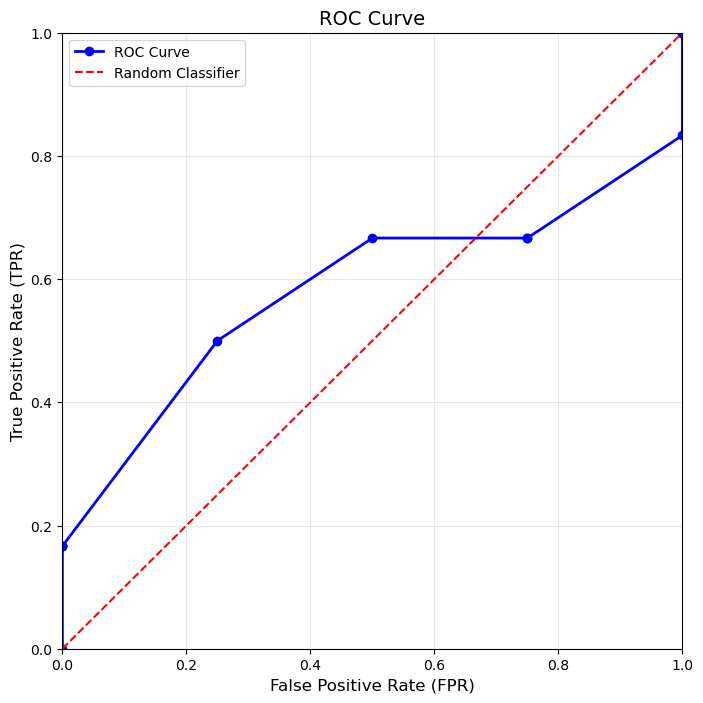

In [5]:
# Plot ROC curve
fpr_list = [point[0] for point in roc_points]
tpr_list = [point[1] for point in roc_points]

plt.figure(figsize=(8, 8))
plt.plot(fpr_list, tpr_list, 'b-o', linewidth=2, markersize=6, label='ROC Curve')
plt.plot([0, 1], [0, 1], 'r--', label='Random Classifier')
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC Curve', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.show()


In [6]:
# Calculate AUC using trapezoidal rule
auc = 0
for i in range(len(roc_points) - 1):
    width = roc_points[i+1][0] - roc_points[i][0]  # Difference in FPR
    height = (roc_points[i+1][1] + roc_points[i][1]) / 2  # Average of TPR
    auc += width * height

print(f"\nAUC = {auc:.4f}")



AUC = 0.5833
